# Klasyfikacja nowotworów piersi z użyciem SVM

**Autor:** Dariusz Gradzik

**Data:** 12.05.2026

**Zbiór danych:** Breast Cancer Wisconsin

## Cel projektu

Zbudować klasyfikator Support Vector Machine rozpoznający, czy guz piersi jest złośliwy, czy łagodny, oraz przeanalizować wpływ:
- parametru regularyzacji **C**
- rodzaju jądra (**linear** vs **rbf**)
- standaryzacji cech ('StandardScaler').

## Opis zbioru danych

W projekcie wykorzystano zbiór Breast Cancer Wisconsin (Diagnostic) dostępny
w bibliotece `scikit-learn` (`sklearn.datasets.load_breast_cancer`). Zbiór zawiera
569 próbek opisanych 30 cechami numerycznymi wyznaczonymi z obrazów cytologicznych
guzów piersi (cienkoigłowa biopsja aspiracyjna, FNA).

Każda próbka opisana jest 10 podstawowymi pomiarami komórek (m.in. promień, tekstura,
obwód, pole, gładkość, wklęsłość, symetria), z których każdy występuje w trzech wariantach:
średnia (`mean`), błąd standardowy (`error`) i wartość największa (`worst`) — łącznie 30 cech.

Klasa docelowa jest binarna:
- `0` — `malignant` (złośliwy) — 212 próbek (37%),
- `1` — `benign` (łagodny) — 357 próbek (63%).

Zbiór jest umiarkowanie niezbalansowany, co uwzględniliśmy stosując stratyfikację przy podziale
na zbiór uczący i testowy.

In [1]:
# Import bibliotek

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
%matplotlib inline

## Eksploracja zbioru
Wczytanie zbioru danych za pomocą funkcji **load_breast_cancer**, wyświetlenie rozmiaru macierzy cech oraz liczby klas

In [2]:
# Wczytanie danych

data = load_breast_cancer()
X = data.data
y = data.target
print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [3]:
# Rozmiar macierzy

print("Rozmiar macierzy cech:", X.shape)

# Liczba klas, nazwy klas, balans klas

print("Liczba klas:", len(data.target_names))
print("Nazwa klas:", data.target_names)
print("Balans klas:")
print(pd.Series(y).value_counts())
print("Lista cech (z indeksami):")
for i, name in enumerate(data.feature_names):
    print(f"  {i:2d}: {name}")

Rozmiar macierzy cech: (569, 30)
Liczba klas: 2
Nazwa klas: ['malignant' 'benign']
Balans klas:
1    357
0    212
Name: count, dtype: int64
Lista cech (z indeksami):
   0: mean radius
   1: mean texture
   2: mean perimeter
   3: mean area
   4: mean smoothness
   5: mean compactness
   6: mean concavity
   7: mean concave points
   8: mean symmetry
   9: mean fractal dimension
  10: radius error
  11: texture error
  12: perimeter error
  13: area error
  14: smoothness error
  15: compactness error
  16: concavity error
  17: concave points error
  18: symmetry error
  19: fractal dimension error
  20: worst radius
  21: worst texture
  22: worst perimeter
  23: worst area
  24: worst smoothness
  25: worst compactness
  26: worst concavity
  27: worst concave points
  28: worst symmetry
  29: worst fractal dimension


## Podział danych na zbiór uczący i testowy

Dzielenie danych w proporcji 70% /  30% przy użyciu 'train_test_split' z 'sklearn.model_selection'.
Argument `random_state` ustawiamy na stałą wartość, aby wyniki były powtarzalne.

In [4]:
# random_state = 42 jako nieoficjalny standard
# dodanie 'stratify' ze względu na nierówny balans pomiędzy klasą 0 i 1. 
# Ta funkcja gwarantuje, że proporcje klas w train i test będą takie same jak w X całościowo

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (398, 30) (398,)
Test: (171, 30) (171,)


## Standaryzacja cech

Standaryzujemy dane za pomocą `StandardScaler`: dopasowujemy parametry transformacji
(średnia, odchylenie standardowe) **wyłącznie na zbiorze uczącym**, a następnie
stosujemy transformację do obu zbiorów. Zapobiega to *data leakage*.

In [5]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Średnia X_train_scaled (pierwsze 5 cech):", X_train_scaled.mean(axis=0)[:5])
print("Odch. std X_train_scaled (pierwsze 5 cech):", X_train_scaled.std(axis=0)[:5])
print("Średnia X_test_scaled  (pierwsze 5 cech):", X_test_scaled.mean(axis=0)[:5])
print("Odch. std X_test_scaled  (pierwsze 5 cech):", X_test_scaled.std(axis=0)[:5])

Średnia X_train_scaled (pierwsze 5 cech): [-4.97480337e-15  2.74863884e-15  2.03912822e-15  1.39921575e-15
  4.32143154e-15]
Odch. std X_train_scaled (pierwsze 5 cech): [1. 1. 1. 1. 1.]
Średnia X_test_scaled  (pierwsze 5 cech): [ 0.0319318  -0.03840967  0.0373941   0.04018951  0.14251303]
Odch. std X_test_scaled  (pierwsze 5 cech): [1.03342124 0.84434077 1.03292105 1.11025615 1.16387741]


Po standaryzacji średnie cech w zbiorze uczącym są bliskie zeru (błąd numeryczny), odchylenia standardowe równe 1. Na zbiorze testowym wartości są bliskie, lecz nieidentyczne (np. średnia 0.03, odch. std 1.03). To potwierdza, że scaler został dopasowany wyłącznie na danych uczących.

## Trening klasyfikatora SVC

Trenujemy klasyfikator `SVC` z domyślnymi parametrami (`C=1.0`, `kernel='rbf'`)
na wystandaryzowanych danych uczących. Następnie obliczamy dokładność na zbiorze
testowym przy użyciu `accuracy_score`.

In [6]:
# 1. Tworzymy obiekt klasyfikatora SVC z domyślnymi parametrami.
#    Argument random_state=42 zapewnia powtarzalność wyników między uruchomieniami.
svc = SVC(random_state=42)

# 2. Trening - model uczy się rozdzielać klasy na wystandaryzowanych danych uczących.
svc.fit(X_train_scaled, y_train)

# 3. Predykcja - model przewiduje klasy dla wystandaryzowanego zbioru testowego.
y_pred = svc.predict(X_test_scaled)

# 4. Obliczenie dokładności klasyfikacji (proporcji poprawnych predykcji).
#    Kolejność argumentów: najpierw etykiety prawdziwe, potem przewidywane.
acc = accuracy_score(y_test, y_pred)

# 5. Wyświetlenie wyniku z formatowaniem do 4 miejsc po przecinku.
print(f"Accuracy (baseline, kernel=rbf, C=1.0): {acc:.4f}")

Accuracy (baseline, kernel=rbf, C=1.0): 0.9766


## Wpływ parametru C i jądra na dokładność

Trenujemy SVC dla różnych wartości C oraz dwóch jąder (`linear`, `rbf`).
Dla każdej konfiguracji mierzymy dokładność na zbiorze testowym.
Wyniki prezentujemy w tabeli posortowanej malejąco po dokładności.

In [7]:
# Lista wartości C i jąder do przetestowania
c_values = [0.01, 0.1, 1, 10, 100]
kernels = ['linear', 'rbf']

# Kontener na wyniki
wyniki = []

for kernel in kernels:
    for c in c_values:
        # Tworzenie modelu SVC z bieżącym C i jądrem
        model = SVC(C=c, kernel=kernel, random_state=42)

        # Trenowanie na X_train_scaled i y_train
        model.fit(X_train_scaled, y_train)

        # Predykcja
        y_pred = model.predict(X_test_scaled)

        # Obliczenie accuracy
        acc = accuracy_score(y_test, y_pred)

        # Dopisanie do listy wynikó
        wyniki.append({
            "kernel": kernel,
            "C": c,
            "accuracy": acc
        })

# Konwersja listy słowników na DataFrame
df_wyniki = pd.DataFrame(wyniki)

# Sortowanie accuracy malejąco
df_wyniki = df_wyniki.sort_values("accuracy", ascending=False).reset_index(drop=True)

# Wyświetlenie
df_wyniki

,kernel,C,accuracy
0,linear,1.00,0.982456
1,rbf,1.00,0.976608
2,rbf,10.00,0.976608
3,linear,0.10,0.970760
4,linear,0.01,0.959064
5,linear,10.00,0.953216
6,linear,100.00,0.941520
7,rbf,0.10,0.935673
8,rbf,100.00,0.923977
9,rbf,0.01,0.625731


Jądro liniowe okazało się lepsze od rbf, co sugeruje, że zbiór po standaryzacji jest w przybliżeniu liniowo separowalny. W takiej sytuacji bardziej elastyczne jądro nie poprawia jakości, a może wręcz zwiększyć ryzyko overfittingu.

Wartości C > 10 prowadzą do spadku accuracy zarówno dla linear, jak i rbf, co potwierdza teoretyczne przewidywanie: zbyt słaba regularyzacja powoduje overfitting modelu do zbioru treningowego.

## Macierz konfuzji - kernel = `linear`, C = 1.0

Trenujemy ponownie najlepszy model liniowy i analizujemy macierz konfuzji
na zbiorze testowym. Macierz pokazuje, gdzie konkretnie model się myli.

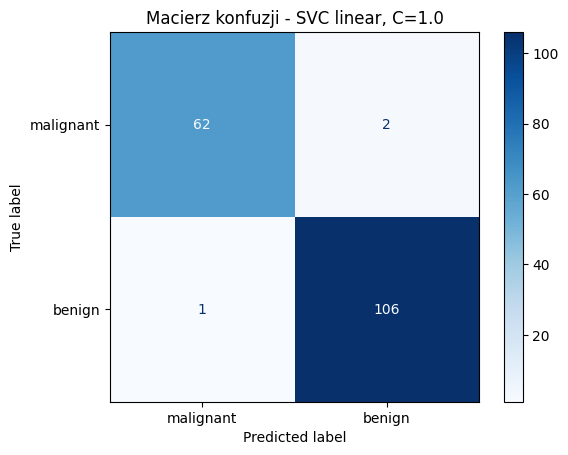

In [8]:
# Tworzenie modelu
model_linear = SVC(C=1, kernel='linear', random_state=42)

# Trenowanie modelu
model_linear.fit(X_train_scaled, y_train)

# Predykcja
y_pred_linear = model_linear.predict(X_test_scaled)

# Obliczanie macierzy konfuzji
cm_linear = confusion_matrix(y_test, y_pred_linear)

# Wyświetlenie macierzy
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=data.target_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Macierz konfuzji - SVC linear, C=1.0")
plt.show()


## Macierz konfuzji - kernel = `rbf`, C = 1.0

Trenujemy ponownie najlepszy model rbf i analizujemy macierz konfuzji
na zbiorze testowym. Macierz pokazuje, gdzie konkretnie model się myli.

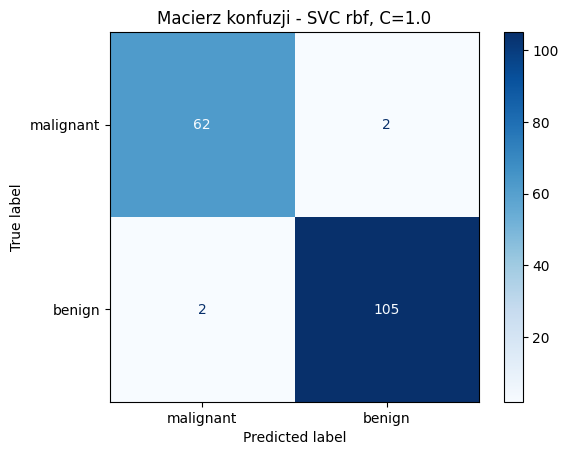

In [9]:
# Tworzenie modelu
model_rbf = SVC(C=1, kernel='rbf', random_state=42)

# Trenowanie modelu
model_rbf.fit(X_train_scaled, y_train)

# Predykcja
y_pred_rbf = model_rbf.predict(X_test_scaled)

# Obliczanie macierzy konfuzji
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

# Wyświetlenie macierzy
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=data.target_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Macierz konfuzji - SVC rbf, C=1.0")
plt.show()

Pomimo niewielkiej różnicy w accuracy (98.25% vs 97.66%), oba modele wykazują identyczną czułość względem klasy malignant (96.9%), omijając dwie pacjentki z chorobą nowotworową. Z perspektywy diagnostyki medycznej modele są zatem równoważne pod względem najgroźniejszego typu błędu. Różnica w accuracy wynika wyłącznie z liczby fałszywych alarmów, które niosą znacznie mniejsze konsekwencje kliniczne. Pokazuje to ograniczenia accuracy jako miary jakości w problemach o niesymetrycznych kosztach błędów.

## Wizualizacja 2D - rzeczywisty vs przewidziany podział klas (linear, C=1.0)

Wykres przedstawia rzut próbek testowych na dwie wybrane cechy:
`mean radius` (oś X) i `mean concave points` (oś Y). Kolor punktu oznacza klasę.
Lewy wykres pokazuje rzeczywiste etykiety, prawy - predykcje modelu `SVC linear`.

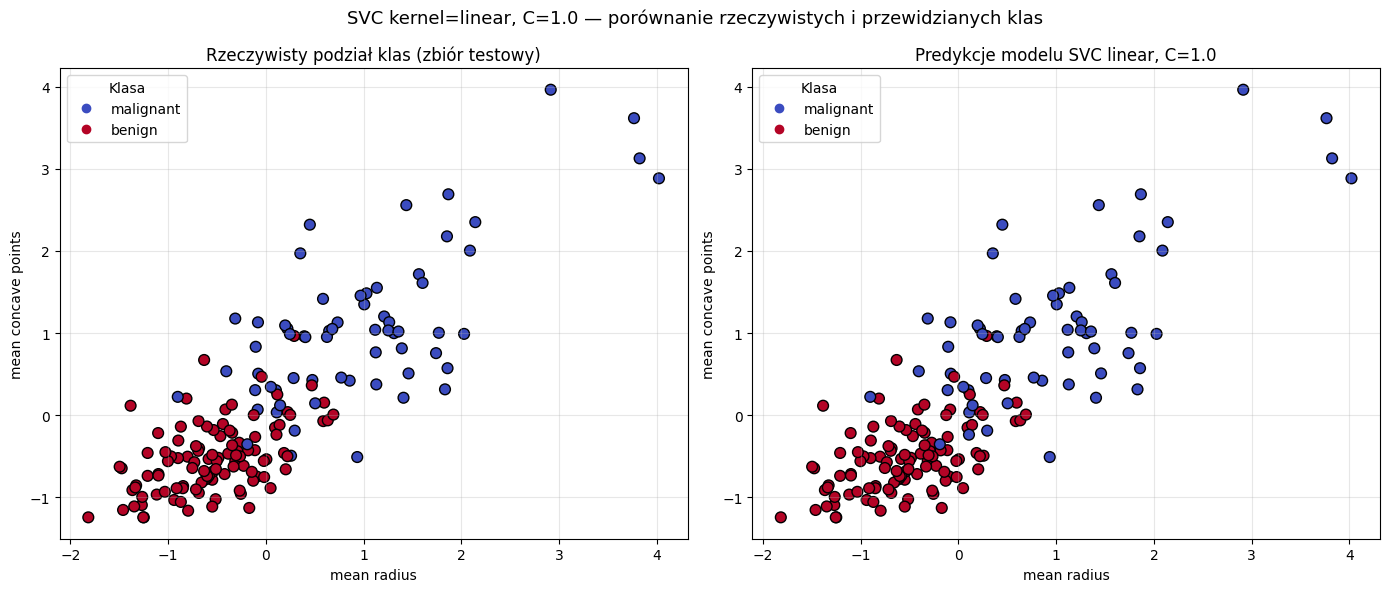

In [10]:
# Wybór cech do wizualizacji (indeksy w macierzy cech)
feature_1 = 0   # mean radius
feature_2 = 7   # mean concave points

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Lewy wykres - rzeczywiste klasy
scatter_real = axes[0].scatter(
    X_test_scaled[:, feature_1],
    X_test_scaled[:, feature_2],
    c=y_test,
    cmap='coolwarm',
    edgecolors='black',
    s=60
)
axes[0].set_title("Rzeczywisty podział klas (zbiór testowy)")
axes[0].set_xlabel(data.feature_names[feature_1])
axes[0].set_ylabel(data.feature_names[feature_2])
axes[0].legend(
    handles=scatter_real.legend_elements()[0],
    labels=list(data.target_names),
    title="Klasa"
)
axes[0].grid(alpha=0.3)

# === Prawy wykres - predykcje modelu linear ===
scatter_pred = axes[1].scatter(
    X_test_scaled[:, feature_1],
    X_test_scaled[:, feature_2],
    c=y_pred_linear,
    cmap='coolwarm',
    edgecolors='black',
    s=60
)
axes[1].set_title("Predykcje modelu SVC linear, C=1.0")
axes[1].set_xlabel(data.feature_names[feature_1])
axes[1].set_ylabel(data.feature_names[feature_2])
axes[1].legend(
    handles=scatter_pred.legend_elements()[0],
    labels=list(data.target_names),
    title="Klasa"
)
axes[1].grid(alpha=0.3)

plt.suptitle("SVC kernel=linear, C=1.0 — porównanie rzeczywistych i przewidzianych klas", fontsize=13)
plt.tight_layout()
plt.show()

## Wizualizacja 2D - rzeczywisty vs przewidziany podział klas (rbf, C=1.0)

Analogiczne porównanie dla modelu z jądrem rbf.

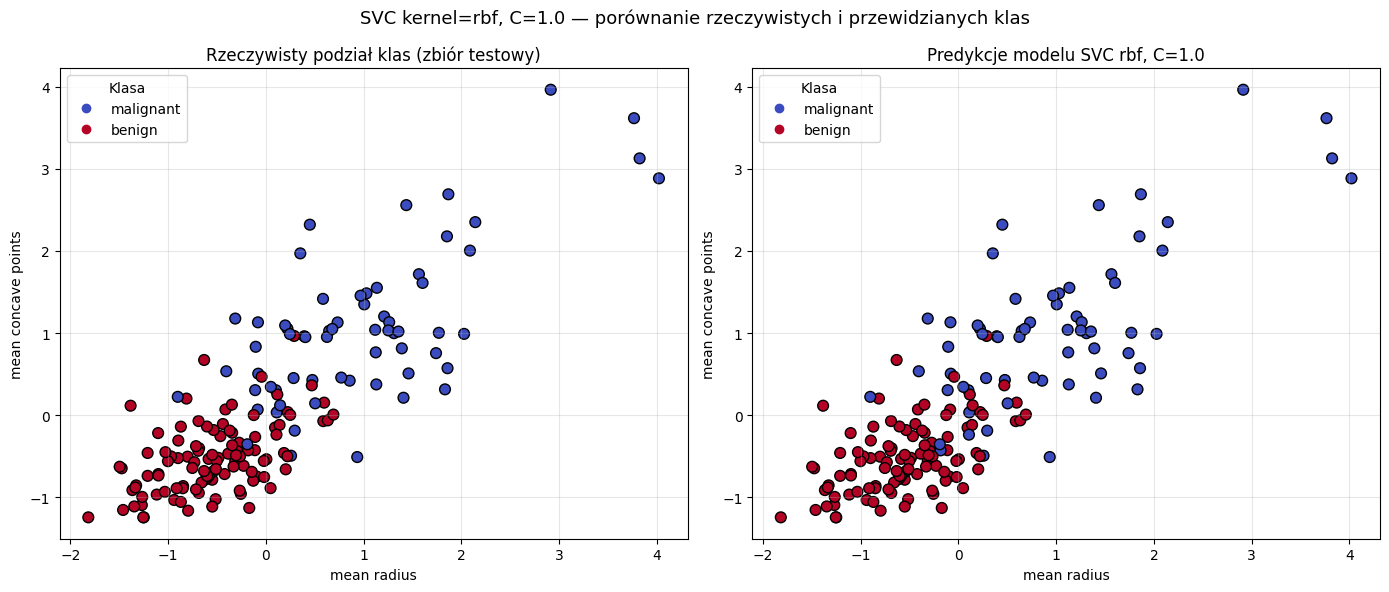

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# === Lewy wykres - rzeczywiste klasy ===
scatter_real = axes[0].scatter(
    X_test_scaled[:, feature_1],
    X_test_scaled[:, feature_2],
    c=y_test,
    cmap='coolwarm',
    edgecolors='black',
    s=60
)
axes[0].set_title("Rzeczywisty podział klas (zbiór testowy)")
axes[0].set_xlabel(data.feature_names[feature_1])
axes[0].set_ylabel(data.feature_names[feature_2])
axes[0].legend(
    handles=scatter_real.legend_elements()[0],
    labels=list(data.target_names),
    title="Klasa"
)
axes[0].grid(alpha=0.3)

# === Prawy wykres - predykcje modelu rbf ===
scatter_pred = axes[1].scatter(
    X_test_scaled[:, feature_1],
    X_test_scaled[:, feature_2],
    c=y_pred_rbf,
    cmap='coolwarm',
    edgecolors='black',
    s=60
)
axes[1].set_title("Predykcje modelu SVC rbf, C=1.0")
axes[1].set_xlabel(data.feature_names[feature_1])
axes[1].set_ylabel(data.feature_names[feature_2])
axes[1].legend(
    handles=scatter_pred.legend_elements()[0],
    labels=list(data.target_names),
    title="Klasa"
)
axes[1].grid(alpha=0.3)

plt.suptitle("SVC kernel=rbf, C=1.0 — porównanie rzeczywistych i przewidzianych klas", fontsize=13)
plt.tight_layout()
plt.show()

## Analiza wpływu standaryzacji

Trenujemy te same konfiguracje (5 wartości C × 2 jądra) **na danych niestandaryzowanych**
i porównujemy z wynikami uzyskanymi na danych standaryzowanych.

W SVM odległości w przestrzeni cech determinują margines i klasyfikację, więc cechy
o większej skali (np. `worst area`) dominują nad cechami o mniejszej skali (np. `mean smoothness`).
Standaryzacja sprowadza wszystkie cechy do porównywalnej skali, dzięki czemu każda
wnosi proporcjonalny wkład do decyzji modelu.

In [12]:
# Eksperyment bez standaryzacji

# Lista wartości C i jąder (te same co poprzednio)
c_values = [0.01, 0.1, 1, 10, 100]
kernels = ['linear', 'rbf']

# Kontener na wyniki - tym razem trenujemy na danych BEZ standaryzacji
wyniki_bez_std = []

for kernel in kernels:
    for c in c_values:
        model = SVC(C=c, kernel=kernel, random_state=42)
        # UWAGA: używamy X_train (nie X_train_scaled) i X_test (nie X_test_scaled)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        wyniki_bez_std.append({
            "kernel": kernel,
            "C": c,
            "accuracy_bez_std": acc
        })

df_bez_std = pd.DataFrame(wyniki_bez_std)
df_bez_std

,kernel,C,accuracy_bez_std
0,linear,0.01,0.953216
1,linear,0.10,0.947368
2,linear,1.00,0.953216
3,linear,10.00,0.953216
4,linear,100.00,0.953216
5,rbf,0.01,0.771930
6,rbf,0.10,0.888889
7,rbf,1.00,0.906433
8,rbf,10.00,0.929825
9,rbf,100.00,0.929825


In [13]:
# Przemianowujemy kolumnę z poprzedniego eksperymentu, żeby było jasne, że to ZE standaryzacją
df_porownanie = df_wyniki.rename(columns={"accuracy": "accuracy_ze_std"})

# Łączymy dwie tabele po kluczach (kernel, C)
df_porownanie = df_porownanie.merge(df_bez_std, on=["kernel", "C"])

# Liczymy różnicę
df_porownanie["roznica"] = df_porownanie["accuracy_ze_std"] - df_porownanie["accuracy_bez_std"]

# Sortujemy po różnicy malejąco
df_porownanie = df_porownanie.sort_values("roznica", ascending=False).reset_index(drop=True)

df_porownanie

,kernel,C,accuracy_ze_std,accuracy_bez_std,roznica
0,rbf,1.00,0.976608,0.906433,0.070175
1,rbf,10.00,0.976608,0.929825,0.046784
2,rbf,0.10,0.935673,0.888889,0.046784
3,linear,1.00,0.982456,0.953216,0.029240
4,linear,0.10,0.970760,0.947368,0.023392
5,linear,0.01,0.959064,0.953216,0.005848
6,linear,10.00,0.953216,0.953216,0.000000
7,rbf,100.00,0.923977,0.929825,-0.005848
8,linear,100.00,0.941520,0.953216,-0.011696
9,rbf,0.01,0.625731,0.771930,-0.146199


Standaryzacja istotnie poprawia dokładność klasyfikatora SVM, szczególnie dla jądra RBF. Dla najlepszej konfiguracji RBF (C=1.0) accuracy wzrosła o 7.0% (z 90.6% do 97.7%). Dla najlepszej konfiguracji liniowej (C=1.0) wzrost wyniósł 2.9% (z 95.3% do 98.2%). Wniosek jest zgodny z teorią: SVM oparte na odległościach (RBF) wymaga standaryzacji, by każda cecha wnosiła proporcjonalny wkład, natomiast model liniowy jest częściowo odporny dzięki zdolności hiperpłaszczyzny do kompensowania skali. Zaobserwowane, korzystne, wyniki bez standaryzacji w skrajnych przypadkach (np. RBF z C=0.01) są artefaktem skali. Przy braku standaryzacji efektywna wartość C nie jest porównywalna między konfiguracjami.

## 12. Wnioski końcowe

### Najlepsza konfiguracja modelu

Najlepszy wynik uzyskano dla konfiguracji `kernel='linear'`, `C=1.0`, osiągając accuracy na zbiorze testowym równe 98.25%. Model `rbf` z `C=1.0` uzyskał nieco niższą accuracy (97.66%), jednak wykazał identyczną czułość względem klasy malignant (recall = 96.9%, dwa false negatives w obu modelach). Z perspektywy diagnostyki medycznej oba modele są zatem równoważne pod względem najgroźniejszego typu błędu, jakim jest przeoczenie przypadku nowotworu złośliwego.

### Wpływ parametru C

Parametr C wpływa na kompromis między marginesem a tolerancją błędów klasyfikacji. Zbyt małe wartości (rzędu 0.01) powodują niedouczenie modelu: klasyfikator staje się trywialny i przewiduje zawsze klasę większościową, osiągając accuracy około 62.6%, co odpowiada baseline'owi klasy benign. Zbyt duże wartości (od 100 wzwyż) prowadzą do przeuczenia, gdyż model próbuje dopasować się do każdego punktu treningowego, co pogarsza jego zdolność generalizacji. Optymalny zakres wartości C dla obu jąder wynosi od 1 do 10.

### Wybór jądra

Na badanym zbiorze, po wcześniejszej standaryzacji, jądro liniowe osiąga lepsze wyniki niż jądro RBF. Sugeruje to, że klasy są w przybliżeniu liniowo separowalne w 30-wymiarowej przestrzeni cech. Zgodnie z zasadą brzytwy Ockhama, w takiej sytuacji wybieramy model prostszy, jeśli jest on wystarczający do rozwiązania problemu.

### Znaczenie standaryzacji

Standaryzacja istotnie poprawiła dokładność klasyfikacji, najmocniej dla jądra RBF (wzrost o około 7 p.p. dla najlepszej konfiguracji), umiarkowanie dla jądra liniowego (wzrost o około 2.9 p.p.). Wynika to z natury algorytmu SVM: klasyfikator operuje na odległościach w przestrzeni cech, w związku z czym cechy o większej skali (na przykład `worst area`) dominowałyby nad cechami o mniejszej skali (na przykład `mean smoothness`). W przypadkach skrajnych (na przykład RBF z C=0.01) brak standaryzacji daje pozornie lepszy wynik, jest to jednak artefakt skali; efektywna wartość parametru C nie jest porównywalna między konfiguracjami trenowanymi na danych o różnych zakresach.

### Ograniczenia i refleksja

Należy zwrócić uwagę na kilka istotnych ograniczeń przeprowadzonej analizy. Po pierwsze, koszty błędów w problemie medycznym są niesymetryczne: false negatives (pacjentka z chorobą sklasyfikowana jako zdrowa) są dramatycznie groźniejsze niż false positives (fałszywy alarm wymagający dodatkowych badań). Optymalizacja accuracy tej asymetrii nie uwzględnia, więc w realnym wdrożeniu warto rozważyć metryki takie jak recall dla klasy mniejszościowej, krzywa ROC, czy dostosowanie progu decyzyjnego klasyfikatora.

Po drugie, liczba próbek (569) jest stosunkowo mała w odniesieniu do liczby cech (30). W dalszej pracy warto zastosować walidację krzyżową (na przykład `StratifiedKFold`), która pozwoli uzyskać stabilniejszą ocenę jakości modelu i ograniczyć zależność wyników od konkretnego podziału na zbiór uczący i testowy.

Po trzecie, w niniejszej pracy nie strojono parametru gamma dla jądra RBF; pozostawiono domyślną wartość `gamma='scale'`. Pełne strojenie hiperparametrów z wykorzystaniem na przykład `GridSearchCV` po obu osiach (C oraz gamma) mogłoby poprawić wyniki dla jądra RBF, choć biorąc pod uwagę zbliżoną liniową separowalność klas, zysk byłby prawdopodobnie umiarkowany.